In [3]:
from test_functions import Satellite
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition, entropy
from active_learning import active_learning_loop

filename = "hist.pt"
x_input = [1,1,1,1,1]

sat_prob = Satellite()
mt_model, train_x_mt, train_y_mt = train_multitask_gp(sat_prob, num_train=10, seed=1111)
mt_model, train_x_mt, train_y_mt = active_learning_loop(mt_model, train_x_mt, train_y_mt, 
                                                        sat_prob, 
                                                        multitask_acquisition(entropy), 
                                                        maxiters = 40, disp = True, 
                                                        save_hist = (x_input, filename))



Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
Iter 31
Iter 32
Iter 33
Iter 34
Iter 35
Iter 36
Iter 37
Iter 38
Iter 39
Iter 40
done


tensor([0.0003])


Text(0, 0.5, 'distance from openMDAO result')

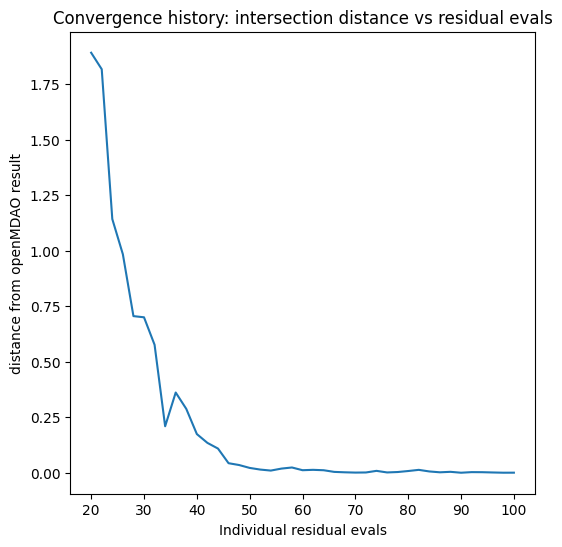

In [6]:
import torch
import matplotlib.pyplot as plt

history = torch.load("hist.pt")
num_evals = history["num_evals"]
dist_history = history["dist_history"]

fig = plt.figure(figsize=(6,6))
host = fig.add_subplot(111)
plt.plot(num_evals, dist_history)
host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

In [6]:
from test_functions import Satellite
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition, entropy
from active_learning import active_learning_loop

for i in list(range(0,10)):
    filename = "hist" + str(i) + ".pt"
    x_input = [1,1,1,1,1]
    
    sat_prob = Satellite()
    mt_model, train_x_mt, train_y_mt = train_multitask_gp(sat_prob, num_train=10)
    mt_model, train_x_mt, train_y_mt = active_learning_loop(mt_model, train_x_mt, train_y_mt, 
                                                            sat_prob, 
                                                            multitask_acquisition(entropy), 
                                                            maxiters = 30, disp = True, 
                                                            save_hist = (x_input, filename))



Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8


Text(0, 0.5, 'distance from openMDAO result')

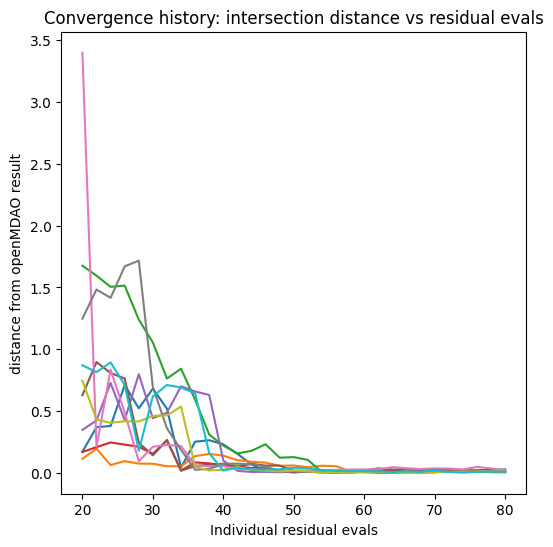

In [7]:
import torch
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6,6))
host = fig.add_subplot(111)

for i in range(0,10):
    history = torch.load("hist" + str(i) + ".pt")
    num_evals = history["num_evals"]
    dist_history = history["dist_history"]
    
    plt.plot(num_evals, dist_history)

host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

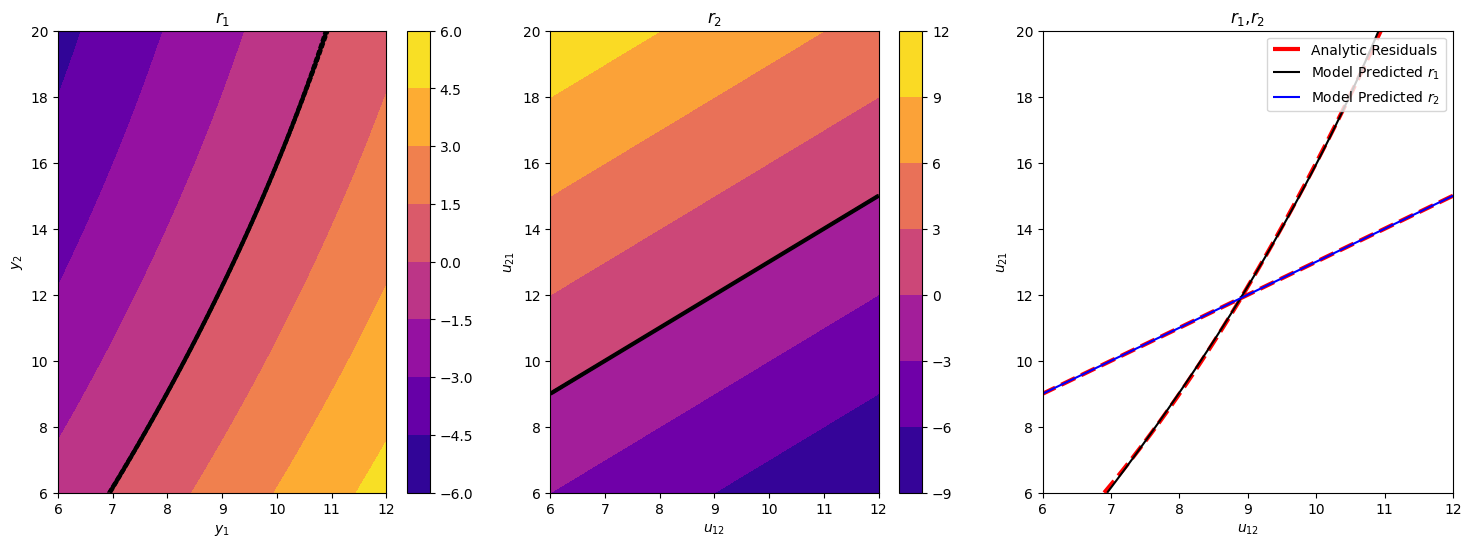

In [8]:
import matplotlib.pyplot as plt
import torch
from botorch.utils.transforms import normalize

# bounds = torch.tensor([[0,0,0,0,0,6,6],[2,2,2,2,2,12,20]])
bounds = sat_prob.bounds

input_vec = torch.ones(1,5)
npts = 40
# xvec is u12, yvec is u21
xvec, yvec = torch.meshgrid(torch.linspace(6.,12.,npts), torch.linspace(6.,20.,npts), indexing='ij')

# Analytic
sat_prob.set_vars(torch.column_stack([input_vec.repeat(1600,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = sat_prob.res[:,0]
r2vec = sat_prob.res[:,1]

# Predictions
test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                             xvec.reshape(-1,1),
                             yvec.reshape(-1,1)])
test_x = normalize(test_x,bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
# test_x1.requires_grad = True

prediction1 = mt_model.likelihood(mt_model(test_x1))
prediction2 = mt_model.likelihood(mt_model(test_x2))

fig = plt.figure(figsize=(18,6))

# r1
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(40,40),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(40,40), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(40, 40) + 2.* prediction1.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(40, 40) - 2.* prediction1.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$y_1$')
ax1.set_ylabel(r'$y_2$')

# r2
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(40,40),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(40,40), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(40, 40) + 2.* prediction2.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(40, 40) - 2.* prediction2.stddev.detach().reshape(40, 40), levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
ax2.set_xlabel(r'$u_{12}$')
ax2.set_ylabel(r'$u_{21}$')

# both
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
#              cmap = 'plasma')
# fig.colorbar(cf3)
s1 = ax3.contour(xvec,yvec,r1vec.reshape(40,40),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(40,40),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(40,40),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(40,40),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='b')
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$,$r_2$')
ax3.set_xlabel(r'$u_{12}$')
ax3.set_ylabel(r'$u_{21}$')
#ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])